In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
fg = pd.read_csv('fear_greed_index.csv')

# Shape
print("Shape:", fg.shape)
print("Rows:", fg.shape[0])
print("Columns:", fg.shape[1])

Shape: (2644, 4)
Rows: 2644
Columns: 4


In [4]:
# Column names
print("Column Names:")
print(fg.columns.tolist())

# Data types of each column
print("\nData Types:")
print(fg.dtypes)

Column Names:
['timestamp', 'value', 'classification', 'date']

Data Types:
timestamp         int64
value             int64
classification      str
date                str
dtype: object


In [5]:
# Check null values in each column
print("Null Values in Each Column:")
print(fg.isnull().sum())

print("\nTotal null values:", fg.isnull().sum().sum())

Null Values in Each Column:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Total null values: 0


In [6]:
# ── Block 4: Duplicate check ──────────────────────────────────────────────────
print("Duplicate rows:", fg.duplicated().sum())

# Drop if any duplicates exist
fg = fg.drop_duplicates()
print("Shape after duplicate drop:", fg.shape)

Duplicate rows: 0
Shape after duplicate drop: (2644, 4)


In [7]:
# ── Block 5: Date validity check ─────────────────────────────────────────────
# Convert date column to proper datetime
fg['date'] = pd.to_datetime(fg['date'])

print("Date range:", fg['date'].min(), "to", fg['date'].max())
print("Duplicate dates:", fg['date'].duplicated().sum())

# Check for gaps (missing days)
full_range = pd.date_range(start=fg['date'].min(), end=fg['date'].max(), freq='D')
missing_days = full_range.difference(fg['date'])
print("Missing days in date range:", len(missing_days))
if len(missing_days) > 0:
    print("Sample missing dates:", missing_days[:5])

Date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Duplicate dates: 0
Missing days in date range: 4
Sample missing dates: DatetimeIndex(['2018-04-14', '2018-04-15', '2018-04-16', '2024-10-26'], dtype='datetime64[us]', freq=None)


In [8]:
# ── Block 6: Identify column types ───────────────────────────────────────────
# Numerical  : value
# Categorical : classification
# Date       : date (already handled)
# Drop       : timestamp (unix number, date column covers it)

fg = fg.drop(columns=['timestamp'])
print("Columns after drop:", fg.columns.tolist())

Columns after drop: ['value', 'classification', 'date']


In [9]:
# ── Block 7: Numerical EDA — describe ────────────────────────────────────────
print("Statistical Summary of 'value' column:")
print(fg['value'].describe())

Statistical Summary of 'value' column:
count    2644.000000
mean       46.981089
std        21.827680
min         5.000000
25%        28.000000
50%        46.000000
75%        66.000000
max        95.000000
Name: value, dtype: float64


Skewness: 0.2017
(Closer to 0 = more symmetric. >1 or <-1 = heavily skewed)


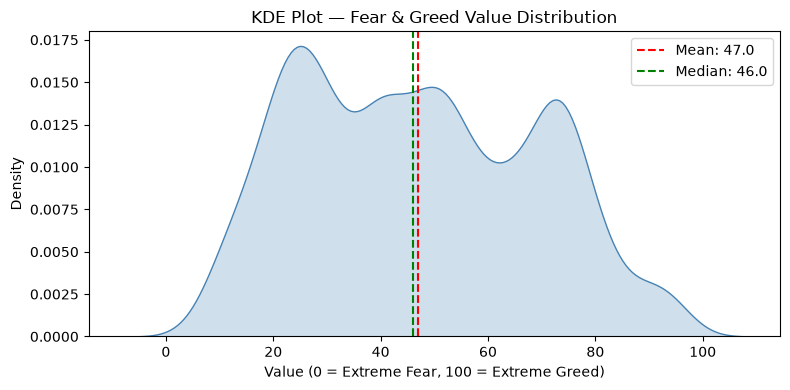

In [10]:
# ── Block 8: Numerical EDA — KDE plot + skewness ─────────────────────────────
print("Skewness:", round(fg['value'].skew(), 4))
print("(Closer to 0 = more symmetric. >1 or <-1 = heavily skewed)")

plt.figure(figsize=(8, 4))
sns.kdeplot(fg['value'], fill=True, color='steelblue')
plt.title('KDE Plot — Fear & Greed Value Distribution')
plt.xlabel('Value (0 = Extreme Fear, 100 = Extreme Greed)')
plt.ylabel('Density')
plt.axvline(fg['value'].mean(), color='red', linestyle='--', label=f"Mean: {fg['value'].mean():.1f}")
plt.axvline(fg['value'].median(), color='green', linestyle='--', label=f"Median: {fg['value'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

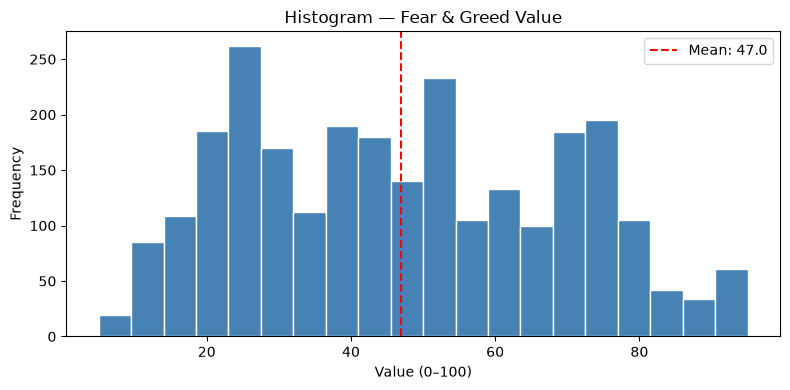

In [11]:
# ── Block 9: Numerical EDA — Histogram ───────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(fg['value'], bins=20, color='steelblue', edgecolor='white')
plt.title('Histogram — Fear & Greed Value')
plt.xlabel('Value (0–100)')
plt.ylabel('Frequency')
plt.axvline(fg['value'].mean(), color='red', linestyle='--', label=f"Mean: {fg['value'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

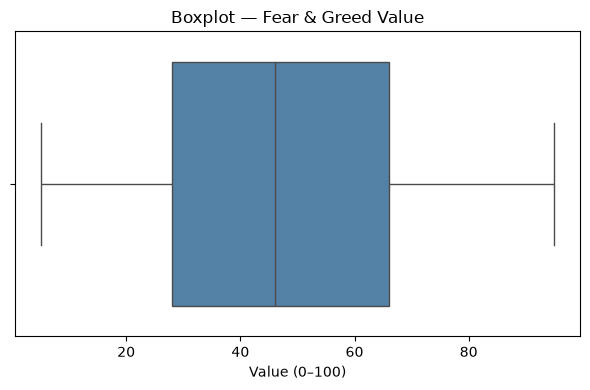

Outliers detected: 0


In [12]:
# ── Block 10: Numerical EDA — Boxplot (outlier detection) ────────────────────
plt.figure(figsize=(6, 4))
sns.boxplot(x=fg['value'], color='steelblue')
plt.title('Boxplot — Fear & Greed Value')
plt.xlabel('Value (0–100)')
plt.tight_layout()
plt.show()

# Print outlier count using IQR method
Q1 = fg['value'].quantile(0.25)
Q3 = fg['value'].quantile(0.75)
IQR = Q3 - Q1
outliers = fg[(fg['value'] < Q1 - 1.5 * IQR) | (fg['value'] > Q3 + 1.5 * IQR)]
print(f"Outliers detected: {len(outliers)}")

In [13]:
# ── Block 11: Categorical EDA — value counts and percentage ──────────────────
print("Classification Value Counts:")
counts = fg['classification'].value_counts()
percent = fg['classification'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': counts, 'Percentage': percent.round(2)})
print(summary)

Classification Value Counts:
                Count  Percentage
classification                   
Fear              781       29.54
Greed             633       23.94
Extreme Fear      508       19.21
Neutral           396       14.98
Extreme Greed     326       12.33


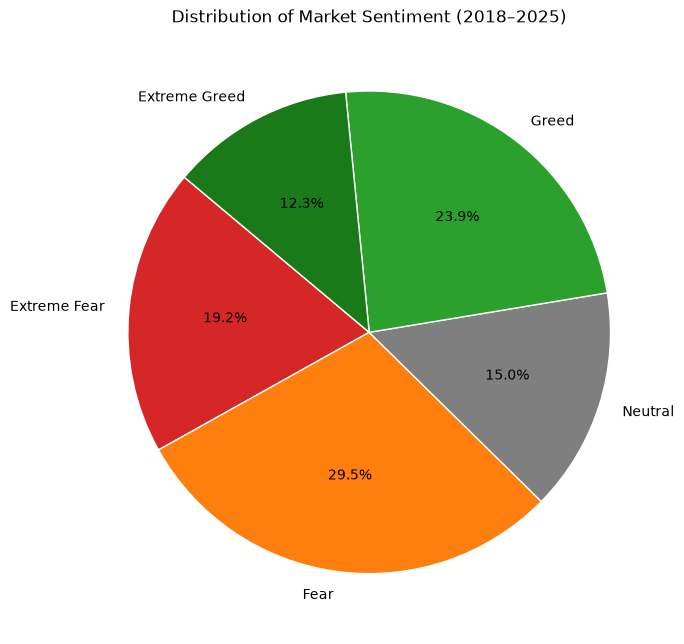

In [14]:
# ── Block 12: Categorical EDA — Pie chart ────────────────────────────────────
colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1a7a1a']
order  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

counts_ordered = fg['classification'].value_counts().reindex(order)

plt.figure(figsize=(7, 7))
plt.pie(counts_ordered, labels=order, autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops={'edgecolor': 'white'})
plt.title('Distribution of Market Sentiment (2018–2025)')
plt.tight_layout()
plt.show()

# ── Notebook 1 Conclusions — Fear & Greed Index ──────────────────────────────

'''
DATASET OVERVIEW
- Total records: 2644 rows, 4 columns (timestamp dropped, 3 remain)
- Date coverage: 1 Feb 2018 to 2 May 2025 — around 7 years of daily data

DATA QUALITY
- No null values found in any column — dataset is complete
- No duplicate rows found
- No duplicate dates — every date is unique, one row per day as expected
- 4 missing days found in the date range — very minor, less than 0.2% of total days, no action needed
- timestamp column dropped as date column already covers it cleanly

NUMERICAL COLUMN — value (Fear/Greed score 0 to 100)
- Mean is 46.98 and Median is 46.0 — both sitting almost at the center of the 0–100 scale
- This tells us Bitcoin market sentiment has been roughly balanced between fear and greed over 7 years
- Min value is 5 and Max is 95 — the market has touched near both extremes but never hit 0 or 100
- Standard deviation is 21.8 — decent spread, market mood swings quite a bit
- Skewness is 0.20 — nearly symmetric distribution, very slight right skew, nothing significant
- KDE and histogram both show a fairly flat, spread-out distribution — no single sentiment dominates heavily
- Boxplot shows 0 outliers using IQR method — every value is within a normal range, no data issues

CATEGORICAL COLUMN — classification
- Fear is the most common sentiment at 29.54% (781 days) — Bitcoin spends the most time in fear
- Greed comes second at 23.94% (633 days)
- Extreme Fear at 19.21% (508 days)
- Neutral at 14.98% (396 days)
- Extreme Greed is the rarest at only 12.33% (326 days) — true euphoria phases are short-lived
- Combined Fear + Extreme Fear = 48.75% — Bitcoin is in some form of fear almost half the time
- Combined Greed + Extreme Greed = 36.27% — greed phases exist but are shorter on average

KEY TAKEAWAY
- The dataset is clean, complete and ready to merge
- Bitcoin leans slightly fearful over its history — fear days outnumber greed days
- Extreme Greed is rare and short — when market goes euphoric, it doesn't stay there long
'''